In [ ]:
import zipfile
import os

# Create a directory to extract files into, if it doesn't exist
extract_dir = 'extracted_data'
os.makedirs(extract_dir, exist_ok=True)

# Unzip the first archive
with zipfile.ZipFile('/content/archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print(f"Extracted /content/archive (1).zip to {extract_dir}/")

# Unzip the second archive
with zipfile.ZipFile('/content/archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print(f"Extracted /content/archive (2).zip to {extract_dir}/")

# List the contents of the extracted directory to verify
print(f"Contents of {extract_dir}/:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Extracted /content/archive (1).zip to extracted_data/
Extracted /content/archive (2).zip to extracted_data/
Contents of extracted_data/:
extracted_data/Automobile.csv


In [ ]:
import pandas as pd

# Load the Automobile.csv file into a pandas DataFrame
df = pd.read_csv('extracted_data/Automobile.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
print(df.head())

# Check the data types and non-null counts
print("\nDataFrame Info:")
df.info()

# Get a statistical summary of the numerical columns
print("\nStatistical Summary of Numerical Columns:")
print(df.describe(include='all'))

First 5 rows of the DataFrame:
                        name   mpg  cylinders  displacement  horsepower  \
0  chevrolet chevelle malibu  18.0          8         307.0       130.0   
1          buick skylark 320  15.0          8         350.0       165.0   
2         plymouth satellite  18.0          8         318.0       150.0   
3              amc rebel sst  16.0          8         304.0       150.0   
4                ford torino  17.0          8         302.0       140.0   

   weight  acceleration  model_year origin  
0    3504          12.0          70    usa  
1    3693          11.5          70    usa  
2    3436          11.0          70    usa  
3    3433          12.0          70    usa  
4    3449          10.5          70    usa  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          398 non-null    object

In [ ]:
import numpy as np

# Handle missing values in 'horsepower' by imputing with the mean
df['horsepower'] = df['horsepower'].replace('?', np.nan).astype(float)
df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)

# Verify that there are no more missing values in 'horsepower'
print("Number of missing values in 'horsepower' after imputation:", df['horsepower'].isnull().sum())

# Drop the 'name' column as it is unique for each car and not useful for regression
df.drop('name', axis=1, inplace=True)
print("\nDataFrame columns after dropping 'name' column:")
print(df.columns)


Number of missing values in 'horsepower' after imputation: 0

DataFrame columns after dropping 'name' column:
Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin'],
      dtype='object')


/tmp/ipython-input-2110762269.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Identify categorical columns for one-hot encoding
categorical_cols = ['origin'] # 'model_year' and 'cylinders' can be treated as numerical for now

# Apply one-hot encoding to categorical columns, dropping one category to avoid multicollinearity
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define the target variable (y) and features (X)
# 'mpg' (miles per gallon) is a common target for prediction in automotive datasets
X = df.drop('mpg', axis=1)
y = df['mpg']

# Split the preprocessed data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit StandardScaler on the training features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform both training and testing features using the fitted scaler
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nFirst 5 rows of X_train_scaled (after one-hot encoding and scaling):\n", X_train_scaled[:5])
print("\nFirst 5 rows of y_train:\n", y_train.head())

Shape of X_train_scaled: (318, 8)
Shape of X_test_scaled: (80, 8)
Shape of y_train: (318,)
Shape of y_test: (80,)

First 5 rows of X_train_scaled (after one-hot encoding and scaling):
 [[ 1.52718818  1.0901965   1.26183446  0.55282624 -1.31933367 -1.6966673
  -0.51176632  0.78895436]
 [-0.85051483 -0.92299623 -0.41351298 -0.99966729 -0.41318225 -1.6966673
   1.95401684 -1.26750044]
 [-0.85051483 -0.98134964 -0.95394763 -1.1247723   0.92792185  1.63897537
   1.95401684 -1.26750044]
 [-0.85051483 -0.98134964 -1.1701215  -1.39285445  0.27549283  0.52709448
   1.95401684 -1.26750044]
 [-0.85051483 -0.74793599 -0.22436085 -0.3276747  -0.23195197 -0.30681619
  -0.51176632 -1.26750044]]

First 5 rows of y_train:
 3      16.0
18     27.0
376    37.0
248    36.1
177    23.0
Name: mpg, dtype: float64


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Instantiate a LinearRegression model object
lr_model = LinearRegression()

# Train the model using the fit method on the scaled training data
lr_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate evaluation metrics
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Print the calculated R-squared, MAE, and RMSE values
print(f"Multiple Linear Regression R-squared: {r2_lr:.4f}")
print(f"Multiple Linear Regression MAE: {mae_lr:.4f}")
print(f"Multiple Linear Regression RMSE: {rmse_lr:.4f}")

Multiple Linear Regression R-squared: 0.8449
Multiple Linear Regression MAE: 2.2876
Multiple Linear Regression RMSE: 2.8878


## Implement Lasso Regression

### Subtask:
Implement and train a Lasso Regression model on the preprocessed training data. Experiment with different alpha (regularization strength) values using cross-validation to find an optimal parameter. Evaluate its performance using R-squared, MAE, and RMSE on the test set.


In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Instantiate a LassoCV model with a range of alphas and 5-fold cross-validation
lasso_model = LassoCV(alphas=np.logspace(-4, 0, 100), cv=5, random_state=42, n_jobs=-1)

# Fit the LassoCV model to the scaled training data
lasso_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Calculate evaluation metrics
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# Print the optimal alpha value
print(f"Optimal Alpha for Lasso Regression: {lasso_model.alpha_:.4f}")

# Print the calculated R-squared, MAE, and RMSE values
print(f"Lasso Regression R-squared: {r2_lasso:.4f}")
print(f"Lasso Regression MAE: {mae_lasso:.4f}")
print(f"Lasso Regression RMSE: {rmse_lasso:.4f}")

Optimal Alpha for Lasso Regression: 0.0266
Lasso Regression R-squared: 0.8436
Lasso Regression MAE: 2.2733
Lasso Regression RMSE: 2.8998


In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Instantiate a RidgeCV model with a range of alphas and 5-fold cross-validation
ridge_model = RidgeCV(alphas=np.logspace(-4, 0, 100), cv=5, random_state=42)

# Fit the RidgeCV model to the scaled training data
ridge_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Calculate evaluation metrics
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# Print the optimal alpha value
print(f"Optimal Alpha for Ridge Regression: {ridge_model.alpha_:.4f}")

# Print the calculated R-squared, MAE, and RMSE values
print(f"Ridge Regression R-squared: {r2_ridge:.4f}")
print(f"Ridge Regression MAE: {mae_ridge:.4f}")
print(f"Ridge Regression RMSE: {rmse_ridge:.4f}")

TypeError: _BaseRidgeCV.__init__() got an unexpected keyword argument 'random_state'

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Instantiate a RidgeCV model with a range of alphas and 5-fold cross-validation
ridge_model = RidgeCV(alphas=np.logspace(-4, 0, 100), cv=5)

# Fit the RidgeCV model to the scaled training data
ridge_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Calculate evaluation metrics
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# Print the optimal alpha value
print(f"Optimal Alpha for Ridge Regression: {ridge_model.alpha_:.4f}")

# Print the calculated R-squared, MAE, and RMSE values
print(f"Ridge Regression R-squared: {r2_ridge:.4f}")
print(f"Ridge Regression MAE: {mae_ridge:.4f}")
print(f"Ridge Regression RMSE: {rmse_ridge:.4f}")

Optimal Alpha for Ridge Regression: 1.0000
Ridge Regression R-squared: 0.8449
Ridge Regression MAE: 2.2824
Ridge Regression RMSE: 2.8875


Model Performance Metrics:
               Model  R-squared       MAE      RMSE
0  Linear Regression   0.844901  2.287587  2.887757
1   Lasso Regression   0.843604  2.273344  2.899807
2   Ridge Regression   0.844923  2.282365  2.887547


/tmp/ipython-input-2149629314.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R-squared', data=metrics_df, ax=axes[0], palette='viridis')
/tmp/ipython-input-2149629314.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=metrics_df, ax=axes[1], palette='plasma')
/tmp/ipython-input-2149629314.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=metrics_df, ax=axes[2], palette='magma')


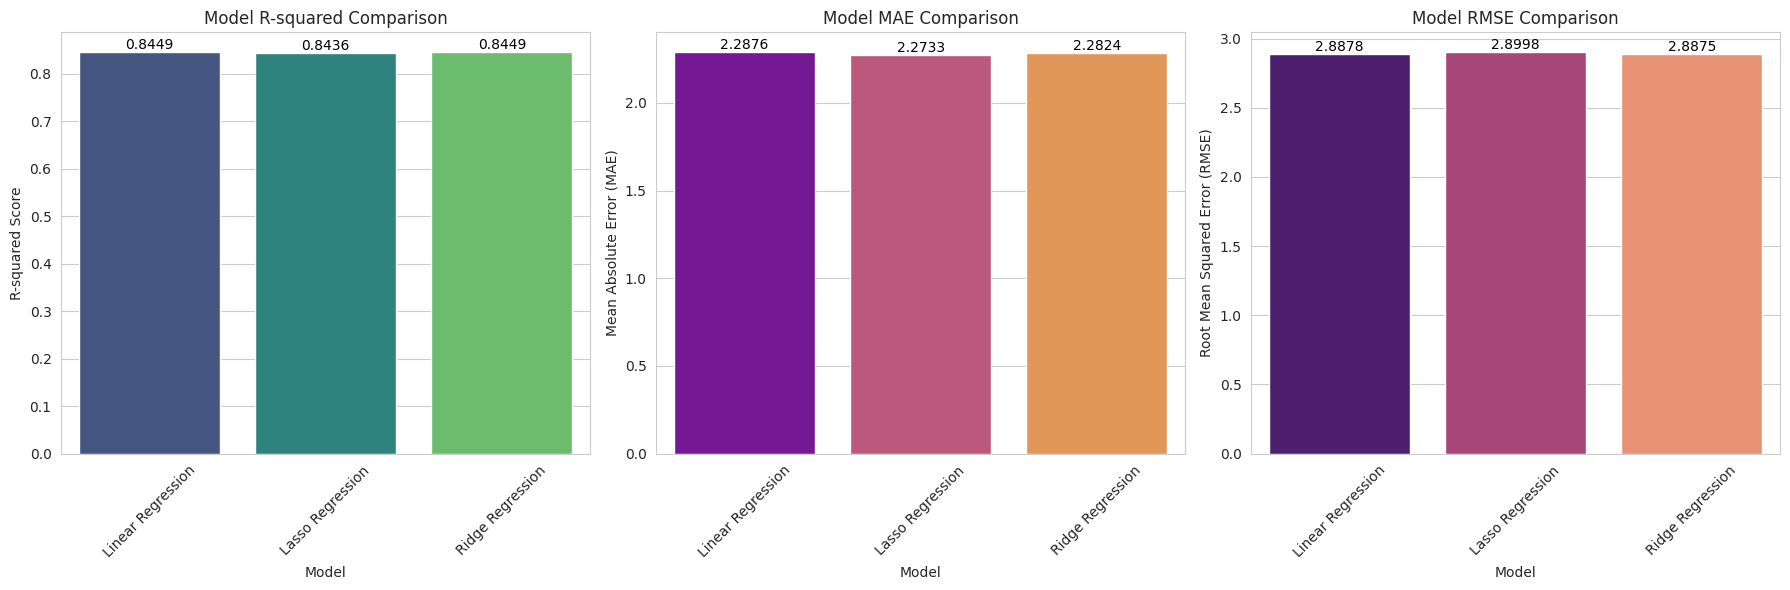

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dictionary to store the evaluation metrics for each model
metrics_data = {
    'Model': ['Linear Regression', 'Lasso Regression', 'Ridge Regression'],
    'R-squared': [r2_lr, r2_lasso, r2_ridge],
    'MAE': [mae_lr, mae_lasso, mae_ridge],
    'RMSE': [rmse_lr, rmse_lasso, rmse_ridge]
}

# Create a DataFrame from the metrics data
metrics_df = pd.DataFrame(metrics_data)

print("Model Performance Metrics:")
print(metrics_df)

# Set a style for the plots
sns.set_style('whitegrid')

# Create subplots for R-squared, MAE, and RMSE comparisons
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

# Bar plot for R-squared
sns.barplot(x='Model', y='R-squared', data=metrics_df, ax=axes[0], palette='viridis')
axes[0].set_title('Model R-squared Comparison')
axes[0].set_ylabel('R-squared Score')
axes[0].tick_params(axis='x', rotation=45)
for index, row in metrics_df.iterrows():
    axes[0].text(index, row['R-squared'], f"{row['R-squared']:.4f}", color='black', ha="center", va='bottom')

# Bar plot for MAE
sns.barplot(x='Model', y='MAE', data=metrics_df, ax=axes[1], palette='plasma')
axes[1].set_title('Model MAE Comparison')
axes[1].set_ylabel('Mean Absolute Error (MAE)')
axes[1].tick_params(axis='x', rotation=45)
for index, row in metrics_df.iterrows():
    axes[1].text(index, row['MAE'], f"{row['MAE']:.4f}", color='black', ha="center", va='bottom')

# Bar plot for RMSE
sns.barplot(x='Model', y='RMSE', data=metrics_df, ax=axes[2], palette='magma')
axes[2].set_title('Model RMSE Comparison')
axes[2].set_ylabel('Root Mean Squared Error (RMSE)')
axes[2].tick_params(axis='x', rotation=45)
for index, row in metrics_df.iterrows():
    axes[2].text(index, row['RMSE'], f"{row['RMSE']:.4f}", color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

Model Performance Metrics:
               Model  R-squared       MAE      RMSE
0  Linear Regression   0.844901  2.287587  2.887757
1   Lasso Regression   0.843604  2.273344  2.899807
2   Ridge Regression   0.844923  2.282365  2.887547


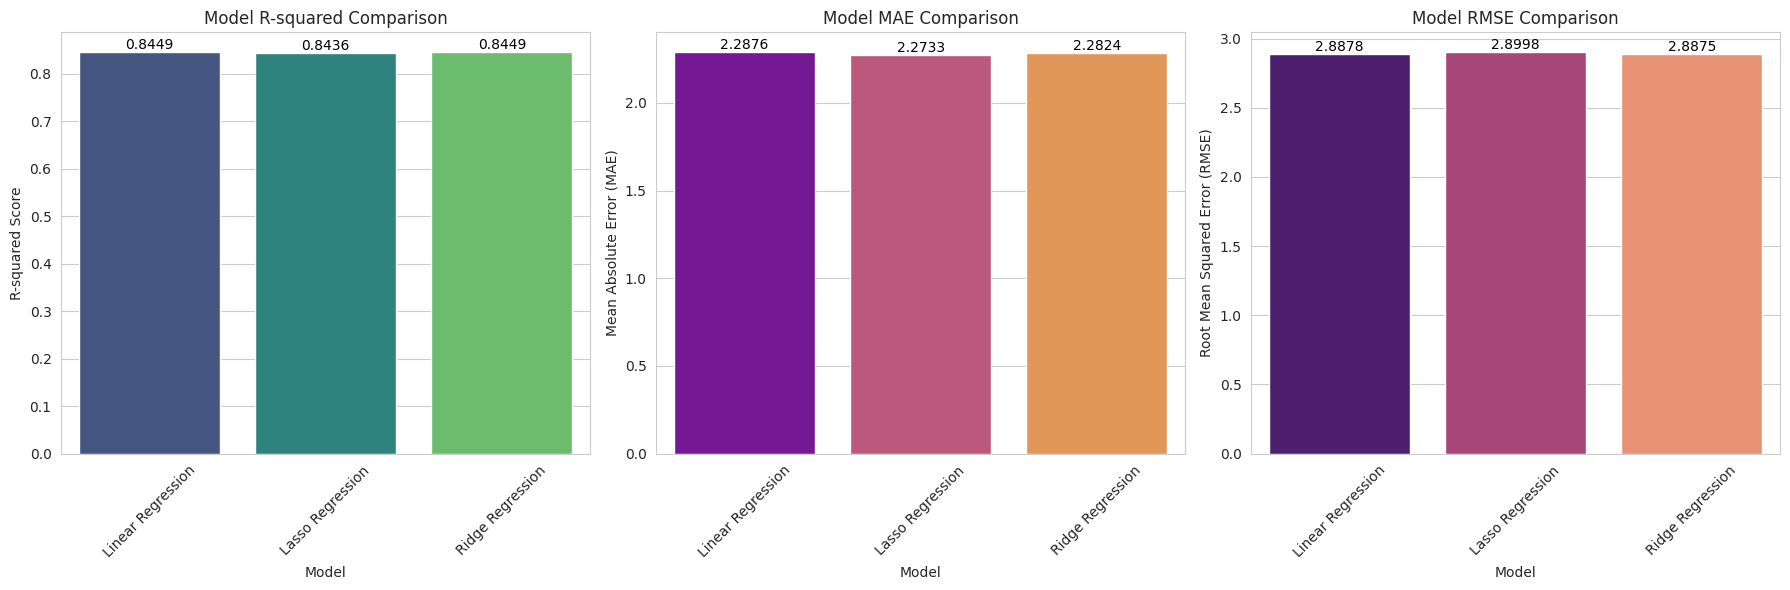

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dictionary to store the evaluation metrics for each model
metrics_data = {
    'Model': ['Linear Regression', 'Lasso Regression', 'Ridge Regression'],
    'R-squared': [r2_lr, r2_lasso, r2_ridge],
    'MAE': [mae_lr, mae_lasso, mae_ridge],
    'RMSE': [rmse_lr, rmse_lasso, rmse_ridge]
}

# Create a DataFrame from the metrics data
metrics_df = pd.DataFrame(metrics_data)

print("Model Performance Metrics:")
print(metrics_df)

# Set a style for the plots
sns.set_style('whitegrid')

# Create subplots for R-squared, MAE, and RMSE comparisons
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

# Bar plot for R-squared
sns.barplot(x='Model', y='R-squared', hue='Model', data=metrics_df, ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Model R-squared Comparison')
axes[0].set_ylabel('R-squared Score')
axes[0].tick_params(axis='x', rotation=45)
for index, row in metrics_df.iterrows():
    axes[0].text(index, row['R-squared'], f"{row['R-squared']:.4f}", color='black', ha="center", va='bottom')

# Bar plot for MAE
sns.barplot(x='Model', y='MAE', hue='Model', data=metrics_df, ax=axes[1], palette='plasma', legend=False)
axes[1].set_title('Model MAE Comparison')
axes[1].set_ylabel('Mean Absolute Error (MAE)')
axes[1].tick_params(axis='x', rotation=45)
for index, row in metrics_df.iterrows():
    axes[1].text(index, row['MAE'], f"{row['MAE']:.4f}", color='black', ha="center", va='bottom')

# Bar plot for RMSE
sns.barplot(x='Model', y='RMSE', hue='Model', data=metrics_df, ax=axes[2], palette='magma', legend=False)
axes[2].set_title('Model RMSE Comparison')
axes[2].set_ylabel('Root Mean Squared Error (RMSE)')
axes[2].tick_params(axis='x', rotation=45)
for index, row in metrics_df.iterrows():
    axes[2].text(index, row['RMSE'], f"{row['RMSE']:.4f}", color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()